
## Chapter 6: Classifying IMDB movie reviews

### Importing the necessary packages

In [3]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

### Utils functions

In [5]:
import numpy as np
import matplotlib
from matplotlib import pyplot as plt

# Some functions to plot our points and draw the lines
def plot_points(features, labels):
    X = np.array(features)
    y = np.array(labels)
    spam = X[np.argwhere(y==1)]
    ham = X[np.argwhere(y==0)]
    plt.scatter([s[0][0] for s in spam],
                   [s[0][1] for s in spam],
                   s = 100,
                   color = 'cyan',
                   edgecolor = 'k',
                   marker = '^')
    plt.scatter([s[0][0] for s in ham],
                   [s[0][1] for s in ham],
                   s = 100,
                   color = 'red',
                   edgecolor = 'k',
                   marker = 's')
    plt.xlabel('aack')
    plt.ylabel('beep')
    plt.legend(['happy','sad'])

def draw_line(a,b,c, color='black', linewidth=2.0, linestyle='solid', starting=0, ending=3):
    # Plotting the line ax + by + c = 0
    x = np.linspace(starting, ending, 1000)
    plt.plot(x, -c/b - a*x/b, linestyle=linestyle, color=color, linewidth=linewidth)

def plot_boundary(features, labels, coefficients_lr, intercept_lr):
    # Define the range for the features
    x_min, x_max = features[:, 0].min() - 1, features[:, 0].max() + 1
    y_min, y_max = features[:, 1].min() - 1, features[:, 1].max() + 1

    # Generate x values for the line
    xx = np.linspace(x_min, x_max, 100)

    # Calculate corresponding y values using the equation of the decision boundary:
    # w0*x0 + w1*x1 + intercept = 0
    # x1 = (-w0*x0 - intercept) / w1
    yy_lr = (-coefficients_lr[0] * xx - intercept_lr) / coefficients_lr[1]

    # Plot the decision boundary (line) for Logistic Regression
    plt.plot(xx, yy_lr, color='orange', linestyle='-', label='Logistic Regression Decision Boundary')

    # Re-plot the original points
    # Separate points based on their labels
    features_label0 = features[labels == 0]
    features_label1 = features[labels == 1]

    # Plot points with label 0 as red squares
    plt.scatter(features_label0[:, 0], features_label0[:, 1], c='red', marker='s', label='Label 0')

    # Plot points with label 1 as blue triangles
    plt.scatter(features_label1[:, 0], features_label1[:, 1], c='blue', marker='^', label='Label 1')

    # Add labels and title
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Logistic Regression Decision Boundary and Data Points')
    plt.legend()
    plt.grid(True)
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.show()

### Loading Dataset

In [6]:
movies = pd.read_csv("IMDB_Dataset.csv")
movies.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### Data Preprocessing

In [7]:
# Relabeling the 'sentiment' column as 0's and 1's
movies['sentiment'] = movies['sentiment'].map({'positive': 1, 'negative': 0})
movies.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [8]:
# Create word features (limit to top 5000 words for efficiency)
vectorizer = CountVectorizer(max_features=2000, stop_words='english')
X = vectorizer.fit_transform(movies['review'])
y = movies['sentiment']

In [9]:
new_movies = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
new_movies.head()

,000,10,100,11,12,13,15,20,30,40,...,year,years,yes,york,young,younger,youth,zero,zombie,zombies
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,1,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


### Train logistic regression (linear model for interpretable weights)

In [10]:
# Train logistic regression (linear model for interpretable weights)
model = LogisticRegression(max_iter=1000)
model.fit(X, y)

LogisticRegression(max_iter=1000)

### See model weights

In [12]:
# Get feature names (words) and their coefficients
# Note, if using a newer version of scikit-learn, change get_feature_names with get_feature_names_out
feature_names = vectorizer.get_feature_names_out()
word_weights = model.coef_[0]  # Weights for positive sentiment

# Create DataFrame of words and their sentiment scores
word_sentiments = pd.DataFrame({
    'word': feature_names,
    'weight': word_weights
})

# Sort words by sentiment strength
most_positive = word_sentiments.sort_values('weight', ascending=False).head(10)
most_negative = word_sentiments.sort_values('weight').head(10)

In [13]:
print(most_positive)
print(most_negative)

             word    weight
1964  wonderfully  1.397547
735      funniest  1.175089
747           gem  1.168884
221   brilliantly  1.110195
1707       subtle  1.087876
1720       superb  1.046548
595     excellent  1.042119
686        finest  1.017862
449    delightful  1.009055
1853   underrated  0.978231
                word    weight
1921           waste -1.911342
491   disappointment -1.701146
1977           worst -1.579128
1009       laughable -1.477435
517         dreadful -1.456082
1858         unfunny -1.450557
142            awful -1.442330
1337          poorly -1.414661
1440       redeeming -1.414073
1756         tedious -1.396740


### Plot top positive/negative words

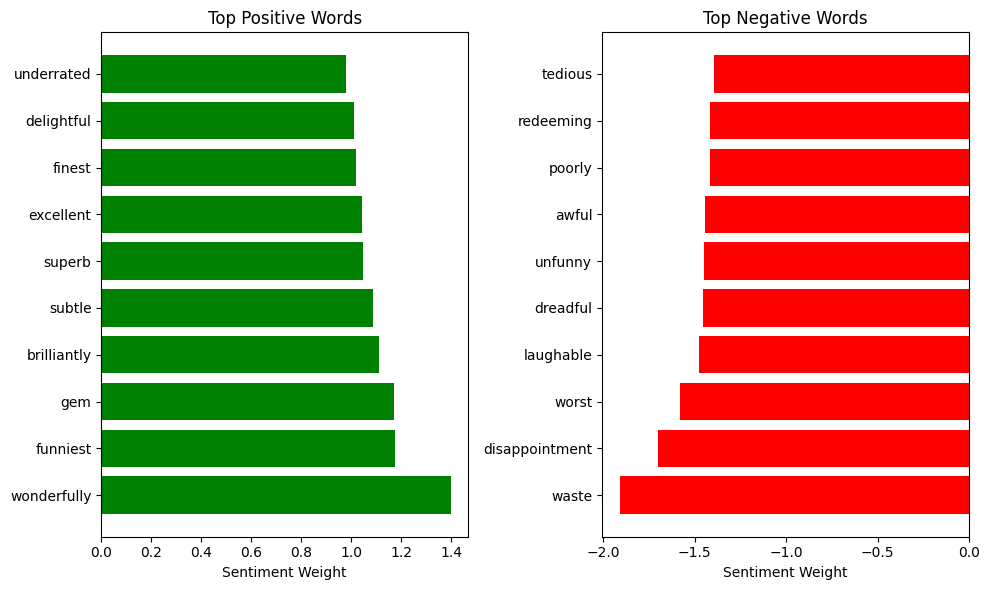

In [14]:
# Plot top positive/negative words
plt.figure(figsize=(10, 6))

# Positive words
plt.subplot(121)
plt.barh(most_positive['word'], most_positive['weight'], color='green')
plt.title('Top Positive Words')
plt.xlabel('Sentiment Weight')

# Negative words
plt.subplot(122)
plt.barh(most_negative['word'], most_negative['weight'], color='red')
plt.title('Top Negative Words')
plt.xlabel('Sentiment Weight')

plt.tight_layout()
plt.show()

### Run predictions

In [15]:
# Predict sentiment scores for all reviews
predictions = model.predict_proba(X)[:, 1]  # Probability of positive sentiment

# Add scores to the DataFrame
movies['predictions'] = predictions

# Find the most positive and negative reviews
most_positive_review = movies.sort_values('predictions', ascending=False).head(1)
most_negative_review = movies.sort_values('predictions').head(1)

print("Most Positive Review:")
display(most_positive_review)

print("\nMost Negative Review:")
display(most_negative_review)

Most Positive Review:


,review,sentiment,predictions
42946,By now you've probably heard a bit about the n...,1,1.0



Most Negative Review:


,review,sentiment,predictions
13452,Zombi 3 starts as a group of heavily armed men...,0,2.524636e-17


In [16]:
print(most_positive_review['review'].iloc[0])

By now you've probably heard a bit about the new Disney dub of Miyazaki's classic film, Laputa: Castle In The Sky. During late summer of 1998, Disney released "Kiki's Delivery Service" on video which included a preview of the Laputa dub saying it was due out in "1999". It's obviously way past that year now, but the dub has been finally completed. And it's not "Laputa: Castle In The Sky", just "Castle In The Sky" for the dub, since Laputa is not such a nice word in Spanish (even though they use the word Laputa many times throughout the dub). You've also probably heard that world renowned composer, Joe Hisaishi, who scored the movie originally, went back to rescore the excellent music with new arrangements. Laputa came out before My Neighbor Totoro and after Nausicaa of the Valley of the Wind, which began Studio Ghibli and it's long string of hits. And in my opinion, I think it's one of Miyazaki's best films with a powerful lesson tuckered inside this two hour and four minute gem. Laputa

In [17]:
print(most_negative_review['review'].iloc[0])

Zombi 3 starts as a group of heavily armed men steal a experimental chemical developed to reanimate the dead, while trying to escape the man is shot at & the metal container holding the chemical is breached. The man gets some of the green chemical on a wound on his hand which soon after turns him into a flesh eating cannibalistic zombie. Within hours the surrounding area is crawling with the flesh easting undead on the look out for fresh victims, Kenny (Deran Sarafian) & his army buddies find themselves in big trouble as they stop to help Patricia (Beatrice Ring) & her friend Lia (Deborah Bergammi) who has been pecked by zombie birds (!). General Morton is in charge of the situation & has to stop the zombie plague from spread throughout the whole world! But will he & his men succeed?<br /><br />This Italian produced film was to be directed by Italian zombie gore film auteur Lucio Fulci but the story goes he suffered a stroke & therefore couldn't finish the film so producer Franco Gaude